In [261]:
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [262]:
# Load the results
#df_sender = pd.read_csv("statistics.csv")
#df_receiver = pd.read_csv("receiver_statistics.csv")


#C:\Users\YSJCOMP\Documents\Publications\! based on PhD\LoRa and encryption Brief Report\code\Results\Results_1\Statistics

#df_sender = pd.read_csv("./Results_6/Statistics/statistics.csv")
#df_receiver = pd.read_csv("./Results_6/receiver_statistics.csv")

df_sender = pd.read_csv("./Results_backwords_1/Statistics/statistics.csv")
df_receiver = pd.read_csv("./Results_backwords_1/receiver_statistics.csv")

In [263]:
df_sender.head()

,Method,File_name,File_size,Chunks_sent,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption
0,CRYSTALS-Kyber,0001q,1032,5,9.08,2.81,9.52,3.86
1,CRYSTALS-Kyber,0001t,768,4,0.00,0.00,0.00,0.00
2,CRYSTALS-Kyber,0002q,1032,5,9.04,2.69,8.92,3.68
3,CRYSTALS-Kyber,0002t,768,4,0.00,0.00,0.00,0.00
4,CRYSTALS-Kyber,0003q,1032,5,9.04,2.68,9.40,3.82


In [264]:
df_receiver.head()

,flag,received_chunks
0,0001q,3
1,0001t,4
2,0002q,5
3,0002t,4
4,0003q,5


In [265]:
# "flag" in the receiver_statistics.csv the same as File_name in the statistics.csv
df_receiver = df_receiver.rename(columns={"flag": "File_name"})

In [266]:
df_receiver.head()

,File_name,received_chunks
0,0001q,3
1,0001t,4
2,0002q,5
3,0002t,4
4,0003q,5


In [267]:
# Merge the results in one df
df = pd.merge(df_sender, df_receiver,
              on="File_name",
              how="left"
)


In [268]:
# Placed Chunks_sent and received_chunks together
ordered_columns = [
    "Method",
    "File_name",
    "File_size",
    "Chunks_sent",
    "received_chunks",   # ← moved received_chunks
    "Transmission_time",
    "Energy_for_transmission",
    "Compression_encryption_time",
    "Energy_for_compression_encryption"
]

df = df[ordered_columns]


In [269]:
df.head()

,Method,File_name,File_size,Chunks_sent,received_chunks,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption
0,CRYSTALS-Kyber,0001q,1032,5,3,9.08,2.81,9.52,3.86
1,CRYSTALS-Kyber,0001t,768,4,4,0.00,0.00,0.00,0.00
2,CRYSTALS-Kyber,0002q,1032,5,5,9.04,2.69,8.92,3.68
3,CRYSTALS-Kyber,0002t,768,4,4,0.00,0.00,0.00,0.00
4,CRYSTALS-Kyber,0003q,1032,5,5,9.04,2.68,9.40,3.82


#### Check if all sent chunks were received

In [270]:
# check if all sent chunks were received
are_equal = df['Chunks_sent'].equals(df['received_chunks'])
are_equal

False

In [271]:
# Compare the two columns element
comparison = df['Chunks_sent'] == df['received_chunks']

# Check through each element
for i, is_equal in enumerate(comparison):
    if not is_equal:
        print(f"Row {i} mismatch: Method={df.loc[i, 'Method']}, File name - {df.loc[i, 'File_name']}, Chunks_sent={df.loc[i, 'Chunks_sent']}, received_chunks={df.loc[i, 'received_chunks']}")

Row 0 mismatch: Method=CRYSTALS-Kyber, File name - 0001q, Chunks_sent=5, received_chunks=3


#### Remove the "Chunks_sent" and "received_chunks" columns
<i>As they already checked</i>

In [272]:
df = df.drop(columns=['Chunks_sent', 'received_chunks'])
df.head()

,Method,File_name,File_size,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption
0,CRYSTALS-Kyber,0001q,1032,9.08,2.81,9.52,3.86
1,CRYSTALS-Kyber,0001t,768,0.00,0.00,0.00,0.00
2,CRYSTALS-Kyber,0002q,1032,9.04,2.69,8.92,3.68
3,CRYSTALS-Kyber,0002t,768,0.00,0.00,0.00,0.00
4,CRYSTALS-Kyber,0003q,1032,9.04,2.68,9.40,3.82


#### Remove the cipher text
<i>as it was needed to check if all chunk in cipher text file were received. All metrics were written in the encrypted file rows.</i>

In [273]:
# Extract the numeric part of File_name (e.g., '0217' from '0217q', '0217t')
df["num_key_temp"] = df["File_name"].astype(str).str.extract(r"(\d+)", expand=False)

In [274]:
# Compute total File_size per numeric key (sum across q/t/others)
size_sum = (
    df.groupby("num_key_temp", as_index=False)["File_size"]
      .sum()
      .rename(columns={"File_size": "File_size_total_temp"})
)

In [275]:
# Map the total size to all rows: Group "0217" → rows: 0217q, 0217t
df = df.merge(size_sum, on="num_key_temp", how="left")

In [276]:
# Remove rows that have 't' in the File_name (case-insensitive) 
df = df[~df["File_name"].str.lower().str.contains("t")].copy()

In [277]:
# Overwrite File_size with the summed total for the numeric group
df.loc[:, "File_size"] = df["File_size_total_temp"]

In [278]:
# Clean up temp columns
df = df.drop(columns=["num_key_temp", "File_size_total_temp"])

#### Remove the "File_name" and  columns
<i>not needed anymmore</i>

In [279]:
df = df.drop(columns=["File_name"])
df

,Method,File_size,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption
0,CRYSTALS-Kyber,1800,9.08,2.81,9.52,3.86
2,CRYSTALS-Kyber,1800,9.04,2.69,8.92,3.68
4,CRYSTALS-Kyber,1800,9.04,2.68,9.40,3.82
6,CRYSTALS-Kyber,1800,9.04,2.71,8.84,3.63
8,CRYSTALS-Kyber,1801,9.04,2.72,9.16,3.76
...,...,...,...,...,...,...
395,VAE,1017,5.03,1.50,9.20,3.80
396,VAE,1016,5.03,1.50,9.42,3.87
397,VAE,1015,5.03,1.52,8.97,3.73
398,VAE,1016,5.03,1.52,9.03,3.74


## Adding additional performance metrics

#### Encryption overhead (%)

In [280]:
# Get unencrypted compressed size values
vae_size = df.loc[df['Method'] == 'VAE', 'File_size'].reset_index(drop=True)

In [281]:
# Create a temp helper column for unencrypted compressed size values
df['VAE_size_temp'] = 0.0

In [282]:
# Write unencrypted compressed size values to each method
for method in ['VAE', 'ChaCha20', 'CRYSTALS-Kyber']:
    df.loc[df['Method'] == method, 'VAE_size_temp'] = vae_size.values

In [283]:
# Creat a column for Encryption overhead size values
df['Encryption_overhead'] = 0.0

In [284]:
# Fill the Encryption overhead and round the values
df['Encryption_overhead'] = ((df['File_size'] - df['VAE_size_temp']) / df['VAE_size_temp']) * 100
df['Encryption_overhead'] = df['Encryption_overhead'].round(2)

In [285]:
# Clean up temp column column
df = df.drop(columns=["VAE_size_temp"])

In [286]:
df

,Method,File_size,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption,Encryption_overhead
0,CRYSTALS-Kyber,1800,9.08,2.81,9.52,3.86,77.17
2,CRYSTALS-Kyber,1800,9.04,2.69,8.92,3.68,77.17
4,CRYSTALS-Kyber,1800,9.04,2.68,9.40,3.82,77.17
6,CRYSTALS-Kyber,1800,9.04,2.71,8.84,3.63,77.34
8,CRYSTALS-Kyber,1801,9.04,2.72,9.16,3.76,77.26
...,...,...,...,...,...,...,...
395,VAE,1017,5.03,1.50,9.20,3.80,0.00
396,VAE,1016,5.03,1.50,9.42,3.87,0.00
397,VAE,1015,5.03,1.52,8.97,3.73,0.00
398,VAE,1016,5.03,1.52,9.03,3.74,0.00


#### Energy for encryption overhead (%)

In [287]:
# Get unencrypted Energy for encryption values
vae_Energy_for_compression_encryption = df.loc[df['Method'] == 'VAE', 'Energy_for_compression_encryption'].reset_index(drop=True)

In [288]:
# Create a temp helper column for unencrypted Energy for encryption values
df['Energy_for_encryption_temp'] = 0.0

In [289]:
# Write unencrypted Energy for encryption values to each method
for method in ['VAE', 'ChaCha20', 'CRYSTALS-Kyber']:
    df.loc[df['Method'] == method, 'Energy_for_encryption_temp'] = vae_Energy_for_compression_encryption.values

In [290]:
# Creat a column for Airtime overhead size values
df['Energy_encryption_overhead'] = 0.0

In [291]:
# Fill the Encryption overhead and round the values
df['Energy_encryption_overhead'] = ((df['Energy_for_compression_encryption'] - df['Energy_for_encryption_temp']) / df['Energy_for_encryption_temp']) * 100
df['Energy_encryption_overhead'] = df['Energy_encryption_overhead'].round(2)

In [292]:
# Clean up temp column column
df = df.drop(columns=['Energy_for_encryption_temp'])

In [293]:
df

,Method,File_size,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption,Encryption_overhead,Energy_encryption_overhead
0,CRYSTALS-Kyber,1800,9.08,2.81,9.52,3.86,77.17,-2.03
2,CRYSTALS-Kyber,1800,9.04,2.69,8.92,3.68,77.17,-1.60
4,CRYSTALS-Kyber,1800,9.04,2.68,9.40,3.82,77.17,1.33
6,CRYSTALS-Kyber,1800,9.04,2.71,8.84,3.63,77.34,-4.97
8,CRYSTALS-Kyber,1801,9.04,2.72,9.16,3.76,77.26,2.45
...,...,...,...,...,...,...,...,...
395,VAE,1017,5.03,1.50,9.20,3.80,0.00,0.00
396,VAE,1016,5.03,1.50,9.42,3.87,0.00,0.00
397,VAE,1015,5.03,1.52,8.97,3.73,0.00,0.00
398,VAE,1016,5.03,1.52,9.03,3.74,0.00,0.00


#### Airtime overhead (%)

In [294]:
# Get unencrypted Transmission time values
vae_Transmission_time = df.loc[df['Method'] == 'VAE', 'Transmission_time'].reset_index(drop=True)

In [295]:
# Create a temp helper column for unencrypted Transmission time values
df['VAE_Transmission_time_temp'] = 0.0

In [296]:
# Write unencrypted Transmission time values to each method
for method in ['VAE', 'ChaCha20', 'CRYSTALS-Kyber']:
    df.loc[df['Method'] == method, 'VAE_Transmission_time_temp'] = vae_Transmission_time.values

In [297]:
# Creat a column for Airtime overhead size values
df['Airtime_overhead'] = 0.0

In [298]:
# Fill the Encryption overhead and round the values
df['Airtime_overhead'] = ((df['Transmission_time'] - df['VAE_Transmission_time_temp']) / df['VAE_Transmission_time_temp']) * 100
df['Airtime_overhead'] = df['Airtime_overhead'].round(2)

In [299]:
# Clean up temp column column
df = df.drop(columns=['VAE_Transmission_time_temp'])

In [300]:
df

,Method,File_size,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption,Encryption_overhead,Energy_encryption_overhead,Airtime_overhead
0,CRYSTALS-Kyber,1800,9.08,2.81,9.52,3.86,77.17,-2.03,80.88
2,CRYSTALS-Kyber,1800,9.04,2.69,8.92,3.68,77.17,-1.60,80.08
4,CRYSTALS-Kyber,1800,9.04,2.68,9.40,3.82,77.17,1.33,80.08
6,CRYSTALS-Kyber,1800,9.04,2.71,8.84,3.63,77.34,-4.97,80.08
8,CRYSTALS-Kyber,1801,9.04,2.72,9.16,3.76,77.26,2.45,80.08
...,...,...,...,...,...,...,...,...,...
395,VAE,1017,5.03,1.50,9.20,3.80,0.00,0.00,0.00
396,VAE,1016,5.03,1.50,9.42,3.87,0.00,0.00,0.00
397,VAE,1015,5.03,1.52,8.97,3.73,0.00,0.00,0.00
398,VAE,1016,5.03,1.52,9.03,3.74,0.00,0.00,0.00


#### Energy for transmission overhead

In [301]:
# Get unencrypted Energy for transmission values
vae_Energy_for_transmission = df.loc[df['Method'] == 'VAE', 'Energy_for_transmission'].reset_index(drop=True)

In [302]:
# Create a temp helper column for unencrypted Energy for transmission values
df['Energy_for_transmission_temp'] = 0.0

In [303]:
# Write unencrypted Energy for transmission values to each method
for method in ['VAE', 'ChaCha20', 'CRYSTALS-Kyber']:
    df.loc[df['Method'] == method, 'Energy_for_transmission_temp'] = vae_Energy_for_transmission.values

In [304]:
# Creat a column for Airtime overhead size values
df['Energy_transmission_overhead'] = 0.0

In [305]:
# Fill the Encryption overhead and round the values
df['Energy_transmission_overhead'] = ((df['Energy_for_transmission'] - df['Energy_for_transmission_temp']) / df['Energy_for_transmission_temp']) * 100
df['Energy_transmission_overhead'] = df['Energy_transmission_overhead'].round(2)

In [306]:
# Clean up temp column column
df = df.drop(columns=['Energy_for_transmission_temp'])

In [307]:
df

,Method,File_size,Transmission_time,Energy_for_transmission,Compression_encryption_time,Energy_for_compression_encryption,Encryption_overhead,Energy_encryption_overhead,Airtime_overhead,Energy_transmission_overhead
0,CRYSTALS-Kyber,1800,9.08,2.81,9.52,3.86,77.17,-2.03,80.88,88.59
2,CRYSTALS-Kyber,1800,9.04,2.69,8.92,3.68,77.17,-1.60,80.08,78.15
4,CRYSTALS-Kyber,1800,9.04,2.68,9.40,3.82,77.17,1.33,80.08,78.67
6,CRYSTALS-Kyber,1800,9.04,2.71,8.84,3.63,77.34,-4.97,80.08,78.29
8,CRYSTALS-Kyber,1801,9.04,2.72,9.16,3.76,77.26,2.45,80.08,80.13
...,...,...,...,...,...,...,...,...,...,...
395,VAE,1017,5.03,1.50,9.20,3.80,0.00,0.00,0.00,0.00
396,VAE,1016,5.03,1.50,9.42,3.87,0.00,0.00,0.00,0.00
397,VAE,1015,5.03,1.52,8.97,3.73,0.00,0.00,0.00,0.00
398,VAE,1016,5.03,1.52,9.03,3.74,0.00,0.00,0.00,0.00


#### Placed all rellated columns together

In [309]:
ordered_columns = [
    "Method",
    
    "File_size",
    "Encryption_overhead",
    
    "Compression_encryption_time",
    "Energy_for_compression_encryption",
    "Energy_encryption_overhead",
      
    "Transmission_time",
    "Airtime_overhead", 
    
    "Energy_for_transmission",
    "Energy_transmission_overhead"    
]

df = df[ordered_columns]

In [310]:
df.head()

,Method,File_size,Encryption_overhead,Compression_encryption_time,Energy_for_compression_encryption,Energy_encryption_overhead,Transmission_time,Airtime_overhead,Energy_for_transmission,Energy_transmission_overhead
0,CRYSTALS-Kyber,1800,77.17,9.52,3.86,-2.03,9.08,80.88,2.81,88.59
2,CRYSTALS-Kyber,1800,77.17,8.92,3.68,-1.60,9.04,80.08,2.69,78.15
4,CRYSTALS-Kyber,1800,77.17,9.40,3.82,1.33,9.04,80.08,2.68,78.67
6,CRYSTALS-Kyber,1800,77.34,8.84,3.63,-4.97,9.04,80.08,2.71,78.29
8,CRYSTALS-Kyber,1801,77.26,9.16,3.76,2.45,9.04,80.08,2.72,80.13


## GRAPHS TO KEEP

#### Graph 1 — Payload size vs Method (bar chart

In [414]:
'''
# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(df["Method"], df["File_size"], color=["#8172B3", "#55A868", "#C44E52"])

# Add labels and title
plt.xlabel("Method")
plt.ylabel("File Size (Bytes)")
plt.xticks(rotation=20, ha="right")

# Show grid on y-axis
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
'''

'\n# Plot bar chart\nplt.figure(figsize=(8, 5))\nplt.bar(df["Method"], df["File_size"], color=["#8172B3", "#55A868", "#C44E52"])\n\n# Add labels and title\nplt.xlabel("Method")\nplt.ylabel("File Size (Bytes)")\nplt.xticks(rotation=20, ha="right")\n\n# Show grid on y-axis\nplt.grid(axis="y", linestyle="--", alpha=0.6)\n\nplt.tight_layout()\n'

#### Graph 2 — Transmission time vs Method (bar chart)

In [415]:
'''
# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(df["Method"], df["Transmission_time"], color=["#8172B3", "#55A868", "#C44E52"])

# Add labels and title
plt.xlabel("Method")
plt.ylabel("Transmission time (Seconds)")
plt.xticks(rotation=20, ha="right")

# Show grid on y-axis
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
'''

'\n# Plot bar chart\nplt.figure(figsize=(8, 5))\nplt.bar(df["Method"], df["Transmission_time"], color=["#8172B3", "#55A868", "#C44E52"])\n\n# Add labels and title\nplt.xlabel("Method")\nplt.ylabel("Transmission time (Seconds)")\nplt.xticks(rotation=20, ha="right")\n\n# Show grid on y-axis\nplt.grid(axis="y", linestyle="--", alpha=0.6)\n\nplt.tight_layout()\n'

#### Graph 3 — Airtime overhead vs Method (bar chart)

In [416]:
'''
# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(df["Method"], df["Airtime_overhead"], color=["#8172B3", "#55A868", "#C44E52"])

# Add labels and title
plt.xlabel("Method")
plt.ylabel("Airtime_overhead (%)")
plt.xticks(rotation=20, ha="right")

# Show grid on y-axis
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
'''

'\n# Plot bar chart\nplt.figure(figsize=(8, 5))\nplt.bar(df["Method"], df["Airtime_overhead"], color=["#8172B3", "#55A868", "#C44E52"])\n\n# Add labels and title\nplt.xlabel("Method")\nplt.ylabel("Airtime_overhead (%)")\nplt.xticks(rotation=20, ha="right")\n\n# Show grid on y-axis\nplt.grid(axis="y", linestyle="--", alpha=0.6)\n\nplt.tight_layout()\n'

#### Graph 4 — Energy for transmission vs Method (bar chart)

In [417]:
'''
# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(df["Method"], df["Energy_for_transmission"], color=["#8172B3", "#55A868", "#C44E52"])

# Add labels and title
plt.xlabel("Method")
plt.ylabel("Energy_for_transmission (Joules)")
plt.xticks(rotation=20, ha="right")

# Show grid on y-axis
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
'''

'\n# Plot bar chart\nplt.figure(figsize=(8, 5))\nplt.bar(df["Method"], df["Energy_for_transmission"], color=["#8172B3", "#55A868", "#C44E52"])\n\n# Add labels and title\nplt.xlabel("Method")\nplt.ylabel("Energy_for_transmission (Joules)")\nplt.xticks(rotation=20, ha="right")\n\n# Show grid on y-axis\nplt.grid(axis="y", linestyle="--", alpha=0.6)\n\nplt.tight_layout()\n'

### Graph 5 — Energy for compression and encryption vs Method (bar chart)

In [418]:
'''
# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(df["Method"], df["Energy_for_compression_encryption"], color=["#8172B3", "#55A868", "#C44E52"])

# Add labels and title
plt.xlabel("Method")
plt.ylabel("Energy_for_compression_encryption (Joules)")
plt.xticks(rotation=20, ha="right")

# Show grid on y-axis
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
'''

'\n# Plot bar chart\nplt.figure(figsize=(8, 5))\nplt.bar(df["Method"], df["Energy_for_compression_encryption"], color=["#8172B3", "#55A868", "#C44E52"])\n\n# Add labels and title\nplt.xlabel("Method")\nplt.ylabel("Energy_for_compression_encryption (Joules)")\nplt.xticks(rotation=20, ha="right")\n\n# Show grid on y-axis\nplt.grid(axis="y", linestyle="--", alpha=0.6)\n\nplt.tight_layout()\n'

# Results Graphs

In [419]:
# Filter each method
vae_df = df[df['Method'] == 'VAE'].reset_index(drop=True)
chacha_df = df[df['Method'] == 'ChaCha20'].reset_index(drop=True)
kyber_df = df[df['Method'] == 'CRYSTALS-Kyber'].reset_index(drop=True)

## Payload Size, Fragmentation, and Reliability

In [434]:
'''
# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(df["Method"], df["File_size"], color=["green", "orange", "deepskyblue"])

# Add labels and title
plt.xlabel("Method")
plt.ylabel("File Size (Bytes)")
plt.xticks(rotation=20, ha="right")

# Show grid on y-axis
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
'''

'\n# Plot bar chart\nplt.figure(figsize=(8, 5))\nplt.bar(df["Method"], df["File_size"], color=["green", "orange", "deepskyblue"])\n\n# Add labels and title\nplt.xlabel("Method")\nplt.ylabel("File Size (Bytes)")\nplt.xticks(rotation=20, ha="right")\n\n# Show grid on y-axis\nplt.grid(axis="y", linestyle="--", alpha=0.6)\n\nplt.tight_layout()\n'

In [452]:
'''
# Desired order
order = ['VAE', 'ChaCha20', 'CRYSTALS-Kyber']

# Reorder DataFrame
df_ordered = (
    df.set_index('Method')
      .loc[order]
      .reset_index()
)

# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(
    df_ordered["Method"],
    df_ordered["File_size"],
    color=["deepskyblue", "orange", "green"]
)

# Add numbers above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.0f}',   # integer formatting
        ha='center',
        va='bottom',
        fontsize=10
    )

# Labels and styling
plt.xlabel("Encryption Method")
plt.ylabel("File Size (Bytes)")
plt.xticks(rotation=0, ha="center")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()
'''

'\n# Desired order\norder = [\'VAE\', \'ChaCha20\', \'CRYSTALS-Kyber\']\n\n# Reorder DataFrame\ndf_ordered = (\n    df.set_index(\'Method\')\n      .loc[order]\n      .reset_index()\n)\n\n# Plot bar chart\nplt.figure(figsize=(8, 5))\nplt.bar(\n    df_ordered["Method"],\n    df_ordered["File_size"],\n    color=["deepskyblue", "orange", "green"]\n)\n\n# Add numbers above bars\nfor bar in bars:\n    height = bar.get_height()\n    plt.text(\n        bar.get_x() + bar.get_width() / 2,\n        height,\n        f\'{height:.0f}\',   # integer formatting\n        ha=\'center\',\n        va=\'bottom\',\n        fontsize=10\n    )\n\n# Labels and styling\nplt.xlabel("Encryption Method")\nplt.ylabel("File Size (Bytes)")\nplt.xticks(rotation=0, ha="center")\nplt.grid(axis="y", linestyle="--", alpha=0.6)\n\nplt.tight_layout()\nplt.show()\n'

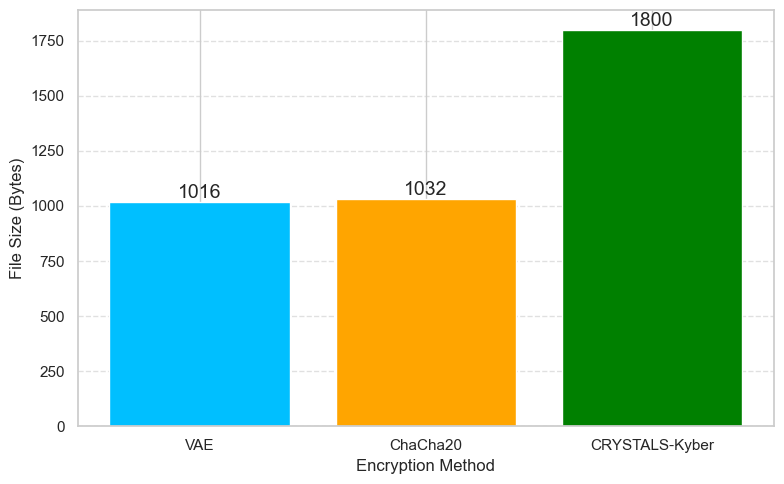

In [453]:
# Desired order
order = ['VAE', 'ChaCha20', 'CRYSTALS-Kyber']

# Compute mean File_size per Method
df_mean = (
    df.groupby('Method', as_index=False)['File_size']
      .mean()
      .set_index('Method')
      .loc[order]
      .reset_index()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    df_mean["Method"],
    df_mean["File_size"],
    color=["deepskyblue", "orange", "green"]
)

# Labels and styling
plt.xlabel("Encryption Method")
plt.ylabel("File Size (Bytes)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.0f}',     # integer formatting
        ha='center',
        va='bottom',
        fontsize=14
    )

plt.tight_layout()
plt.show()

## Compression and Encryption Processing

### Compression Encryption Time vs Energy Consumption

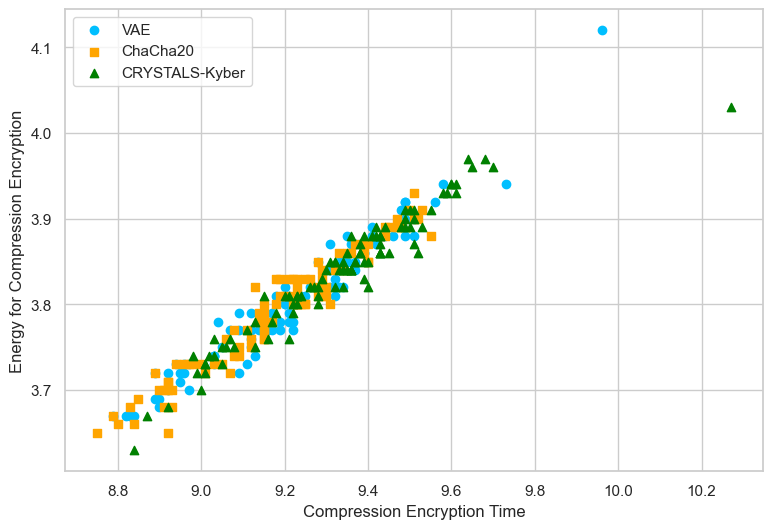

In [427]:

# Filter each method
#vae_df = df[df['Method'] == 'VAE']
#chacha_df = df[df['Method'] == 'ChaCha20']
#kyber_df = df[df['Method'] == 'CRYSTALS-Kyber']

plt.figure(figsize=(9,6))

# Scatter plots
plt.scatter(
    vae_df['Compression_encryption_time'],
    vae_df['Energy_for_compression_encryption'],
    marker='o',
    color='deepskyblue',
    label='VAE'
)

plt.scatter(
    chacha_df['Compression_encryption_time'],
    chacha_df['Energy_for_compression_encryption'],
    marker='s',
    color='orange',
    label='ChaCha20'
)

plt.scatter(
    kyber_df['Compression_encryption_time'],
    kyber_df['Energy_for_compression_encryption'],
    marker='^',
    color='green',
    label='CRYSTALS-Kyber'
)

# Labels and styling
#plt.title('Compression Encryption Time vs Energy Consumption')
plt.xlabel('Compression Encryption Time')
plt.ylabel('Energy for Compression Encryption')
plt.grid(True)
plt.legend(loc='upper left')
plt.show()


### Comparison: Energy for compression and encryption

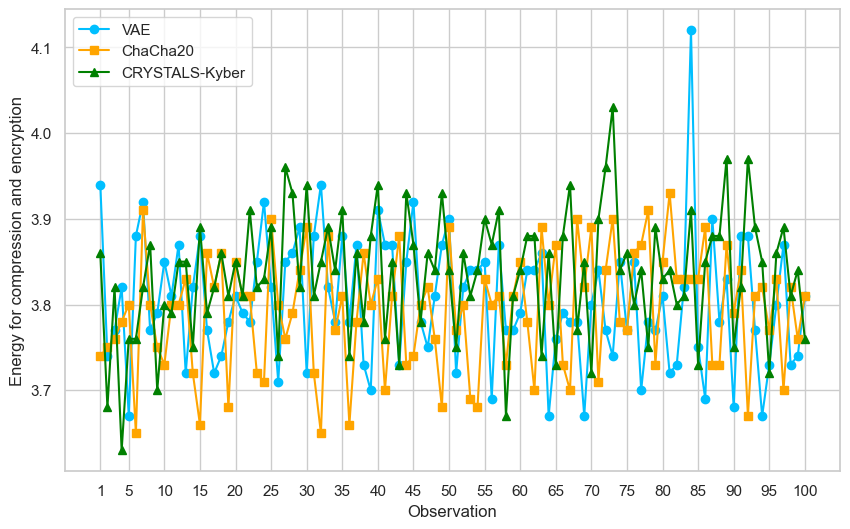

In [426]:


# Filter each method
#vae_df = df[df['Method'] == 'VAE'].reset_index(drop=True)
#chacha_df = df[df['Method'] == 'ChaCha20'].reset_index(drop=True)
#kyber_df = df[df['Method'] == 'CRYSTALS-Kyber'].reset_index(drop=True)

plt.figure(figsize=(10,6))

# Plot each method
plt.plot(vae_df.index + 1, vae_df['Energy_for_compression_encryption'], marker='o', linestyle='-', color='deepskyblue', label='VAE')
plt.plot(chacha_df.index + 1, chacha_df['Energy_for_compression_encryption'], marker='s', linestyle='-', color='orange', label='ChaCha20')
plt.plot(kyber_df.index + 1, kyber_df['Energy_for_compression_encryption'], marker='^', linestyle='-', color='green', label='CRYSTALS-Kyber')

# Customize x-axis to show specific ticks
plt.xticks([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])

# Add labels, legend, grid
#plt.title('Comparison: Energy for compression and encryption')
plt.xlabel('Observation')
plt.ylabel('Energy for compression and encryption')
plt.grid(True)
plt.legend(loc='upper left')
plt.show()


### Comparison: Energy for encryption overhead

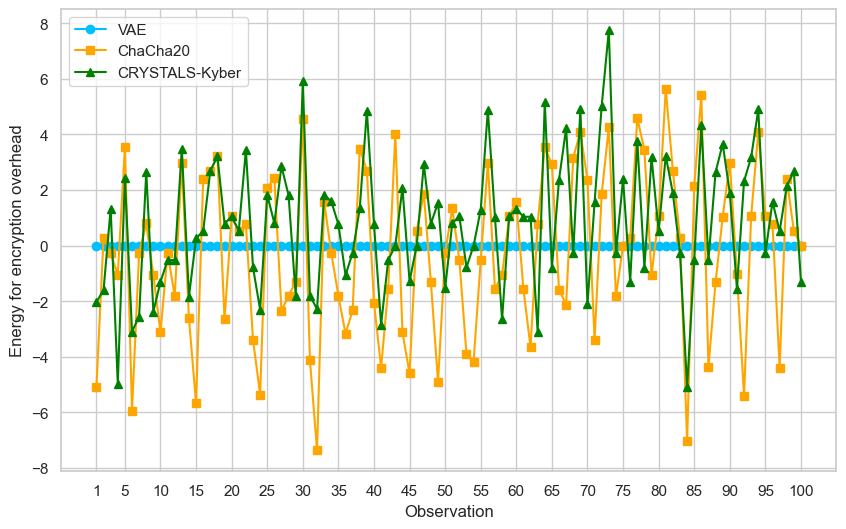

In [425]:


# Filter each method
#vae_df = df[df['Method'] == 'VAE'].reset_index(drop=True)
#chacha_df = df[df['Method'] == 'ChaCha20'].reset_index(drop=True)
#kyber_df = df[df['Method'] == 'CRYSTALS-Kyber'].reset_index(drop=True)

plt.figure(figsize=(10,6))

# Plot each method
plt.plot(vae_df.index + 1, vae_df['Energy_encryption_overhead'], marker='o', linestyle='-', color='deepskyblue', label='VAE')
plt.plot(chacha_df.index + 1, chacha_df['Energy_encryption_overhead'], marker='s', linestyle='-', color='orange', label='ChaCha20')
plt.plot(kyber_df.index + 1, kyber_df['Energy_encryption_overhead'], marker='^', linestyle='-', color='green', label='CRYSTALS-Kyber')

# Customize x-axis to show specific ticks
plt.xticks([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])

# Add labels, legend, grid
#plt.title('Comparison: Energy for encryption overhead')
plt.xlabel('Observation')
plt.ylabel('Energy for encryption overhead')
plt.grid(True)
plt.legend(loc='upper left')
plt.show()


###### Local processing energy

Energy consumption for preparation (joules) vs Energy for encryption overhead (%)

In [339]:
'''
import matplotlib.pyplot as plt

# Filter each method
#vae_df = df[df['Method'] == 'VAE']
#chacha_df = df[df['Method'] == 'ChaCha20']
#kyber_df = df[df['Method'] == 'CRYSTALS-Kyber']

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# --- VAE ---
axes[0].plot(
    vae_df['Energy_for_compression_encryption'],
    vae_df['Energy_encryption_overhead'],
    marker='o',
    linestyle='-'
)
axes[0].set_title('VAE', fontsize=16)
axes[0].set_xlabel('Energy for compression encryption', fontsize=16)
axes[0].set_ylabel('Energy encryption overhead', fontsize=16)
axes[0].grid(True)

# --- ChaCha20 ---
axes[1].plot(
    chacha_df['Energy_for_compression_encryption'],
    chacha_df['Energy_encryption_overhead'],
    marker='s',
    linestyle='-'
)
axes[1].set_title('ChaCha20', fontsize=16)
axes[1].set_xlabel('Energy for compression encryption', fontsize=16)
axes[1].grid(True)

# --- CRYSTALS-Kyber ---
axes[2].plot(
    kyber_df['Energy_for_compression_encryption'],
    kyber_df['Energy_encryption_overhead'],
    marker='^',
    linestyle='-'
)
axes[2].set_title('CRYSTALS-Kyber', fontsize=16)
axes[2].set_xlabel('Energy for compression encryption', fontsize=16)
axes[2].grid(True)

# Overall title
fig.suptitle('Energy for compression encryption vs Energy for compression encryption', fontsize=20)

plt.tight_layout()
plt.show()
'''

"\nimport matplotlib.pyplot as plt\n\n# Filter each method\n#vae_df = df[df['Method'] == 'VAE']\n#chacha_df = df[df['Method'] == 'ChaCha20']\n#kyber_df = df[df['Method'] == 'CRYSTALS-Kyber']\n\n# Create subplots: 1 row, 3 columns\nfig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)\n\n# --- VAE ---\naxes[0].plot(\n    vae_df['Energy_for_compression_encryption'],\n    vae_df['Energy_encryption_overhead'],\n    marker='o',\n    linestyle='-'\n)\naxes[0].set_title('VAE', fontsize=16)\naxes[0].set_xlabel('Energy for compression encryption', fontsize=16)\naxes[0].set_ylabel('Energy encryption overhead', fontsize=16)\naxes[0].grid(True)\n\n# --- ChaCha20 ---\naxes[1].plot(\n    chacha_df['Energy_for_compression_encryption'],\n    chacha_df['Energy_encryption_overhead'],\n    marker='s',\n    linestyle='-'\n)\naxes[1].set_title('ChaCha20', fontsize=16)\naxes[1].set_xlabel('Energy for compression encryption', fontsize=16)\naxes[1].grid(True)\n\n# --- CRYSTALS-Kyber ---\naxes[2].plot(\

## Transmission processing

### Transmission time

In [437]:
'''
# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(df["Method"], df["Transmission_time"], color=["green", "orange", "deepskyblue"])

# Add labels and title
plt.xlabel("Method")
plt.ylabel("Transmission time (Seconds)")
plt.xticks(rotation=20, ha="right")

# Show grid on y-axis
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
'''

'\n# Plot bar chart\nplt.figure(figsize=(8, 5))\nplt.bar(df["Method"], df["Transmission_time"], color=["green", "orange", "deepskyblue"])\n\n# Add labels and title\nplt.xlabel("Method")\nplt.ylabel("Transmission time (Seconds)")\nplt.xticks(rotation=20, ha="right")\n\n# Show grid on y-axis\nplt.grid(axis="y", linestyle="--", alpha=0.6)\n\nplt.tight_layout()\n'

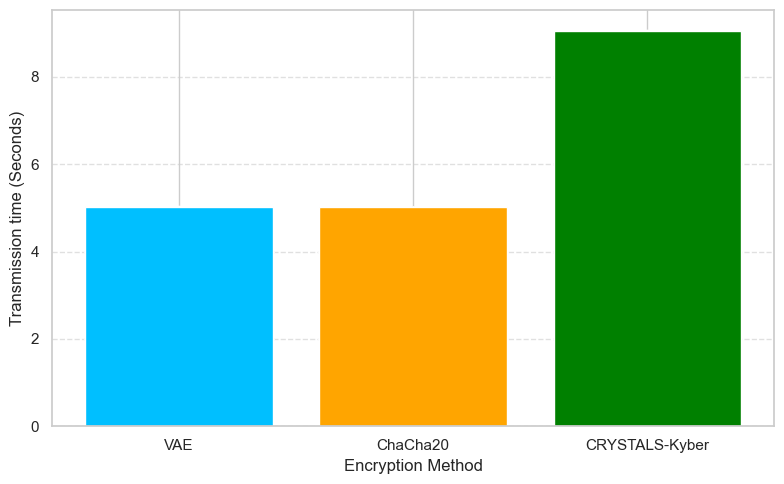

In [455]:
# Desired order
order = ['VAE', 'ChaCha20', 'CRYSTALS-Kyber']

# Reorder DataFrame
df_ordered = (
    df.set_index('Method')
      .loc[order]
      .reset_index()
)

# Plot bar chart
plt.figure(figsize=(8, 5))
plt.bar(
    df_ordered["Method"],
    df_ordered["Transmission_time"],
    color=["deepskyblue", "orange", "green"]
)

# Labels and styling
plt.xlabel("Encryption Method")
plt.ylabel("Transmission time (Seconds)")
plt.xticks(rotation=0, ha="center")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


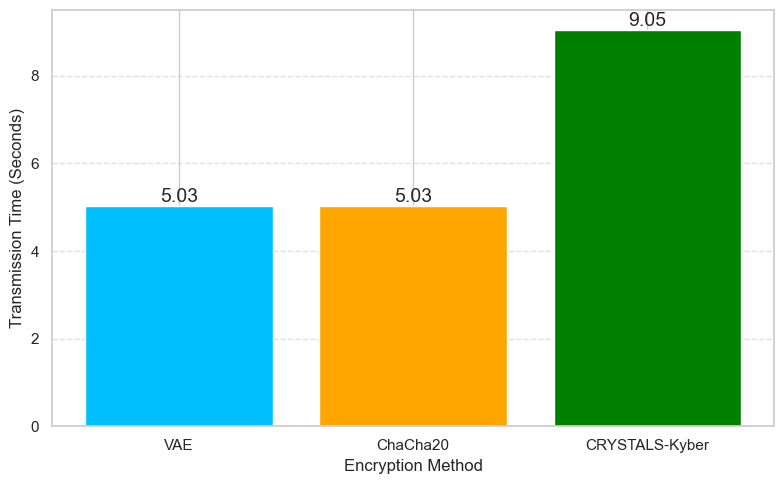

In [457]:
# Desired order
order = ['VAE', 'ChaCha20', 'CRYSTALS-Kyber']

# Compute mean Transmission_time per method
df_mean = (
    df.groupby('Method', as_index=False)['Transmission_time']
      .mean()
)

# Reorder DataFrame
df_ordered = (
    df_mean.set_index('Method')
           .loc[order]
           .reset_index()
)

# Plot bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(
    df_ordered["Method"],
    df_ordered["Transmission_time"],
    color=["deepskyblue", "orange", "green"]
)

# Add numbers above bars (mean values)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=14
    )

# Labels and styling
plt.xlabel("Encryption Method")
plt.ylabel("Transmission Time (Seconds)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [389]:
'''

# Filter each method
#vae_df = df[df['Method'] == 'VAE'].reset_index(drop=True)
#chacha_df = df[df['Method'] == 'ChaCha20'].reset_index(drop=True)
#kyber_df = df[df['Method'] == 'CRYSTALS-Kyber'].reset_index(drop=True)

plt.figure(figsize=(10,6))

# Plot each method
plt.plot(vae_df.index + 1, vae_df['Energy_for_transmission'], marker='o', linestyle='-', color='skyblue', label='VAE')
plt.plot(chacha_df.index + 1, chacha_df['Energy_for_transmission'], marker='s', linestyle='-', color='orange', label='ChaCha20')
plt.plot(kyber_df.index + 1, kyber_df['Energy_for_transmission'], marker='^', linestyle='-', color='green', label='CRYSTALS-Kyber')

# Customize x-axis to show specific ticks
plt.xticks([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])

# Add labels, legend, grid
plt.title('Comparison: Energy for transmission')
plt.xlabel('Observation')
plt.ylabel('Energy for transmission')
plt.grid(True)
plt.legend()
plt.show()
'''

"\n\n# Filter each method\n#vae_df = df[df['Method'] == 'VAE'].reset_index(drop=True)\n#chacha_df = df[df['Method'] == 'ChaCha20'].reset_index(drop=True)\n#kyber_df = df[df['Method'] == 'CRYSTALS-Kyber'].reset_index(drop=True)\n\nplt.figure(figsize=(10,6))\n\n# Plot each method\nplt.plot(vae_df.index + 1, vae_df['Energy_for_transmission'], marker='o', linestyle='-', color='skyblue', label='VAE')\nplt.plot(chacha_df.index + 1, chacha_df['Energy_for_transmission'], marker='s', linestyle='-', color='orange', label='ChaCha20')\nplt.plot(kyber_df.index + 1, kyber_df['Energy_for_transmission'], marker='^', linestyle='-', color='green', label='CRYSTALS-Kyber')\n\n# Customize x-axis to show specific ticks\nplt.xticks([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])\n\n# Add labels, legend, grid\nplt.title('Comparison: Energy for transmission')\nplt.xlabel('Observation')\nplt.ylabel('Energy for transmission')\nplt.grid(True)\nplt.legend()\nplt.show()\n"

### Comparison: Energy for transmission

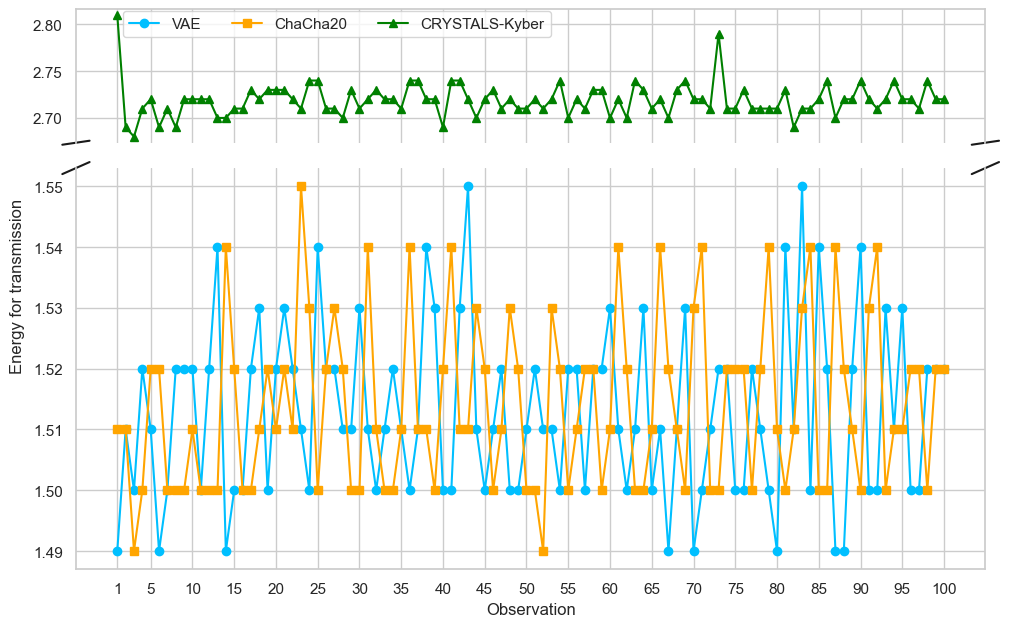

In [430]:
#import matplotlib.pyplot as plt

# Filter each method
#vae_df = df[df['Method'] == 'VAE'].reset_index(drop=True)
#chacha_df = df[df['Method'] == 'ChaCha20'].reset_index(drop=True)
#kyber_df = df[df['Method'] == 'CRYSTALS-Kyber'].reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(10, 7),
    gridspec_kw={'height_ratios': [1, 3]}
)

# --- Upper axis (Kyber) ---
line_kyber, = ax1.plot(
    kyber_df.index + 1,
    kyber_df['Energy_for_transmission'],
    marker='^',
    linestyle='-',
    color='green',
    label='CRYSTALS-Kyber'
)

# --- Lower axis (VAE + ChaCha20) ---
line_vae, = ax2.plot(
    vae_df.index + 1,
    vae_df['Energy_for_transmission'],
    marker='o',
    linestyle='-',
    color='deepskyblue',
    label='VAE'
)

line_chacha, = ax2.plot(
    chacha_df.index + 1,
    chacha_df['Energy_for_transmission'],
    marker='s',
    linestyle='-',
    color='orange',
    label='ChaCha20'
)

# --- Broken axis styling ---
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.tick_params(labeltop=False)

d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# --- Labels ---
#fig.suptitle('Comparison: Energy for Transmission Overhead', fontsize=14)
ax2.set_xlabel('Observation')
#ax1.set_ylabel('Energy')
#ax2.set_ylabel('Energy')
fig.text(-0.005, 0.5, 'Energy for transmission', va='center', rotation='vertical')


ax1.grid(True)
ax2.grid(True)

ax2.set_xticks([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])

# Single shared legend
fig.legend(
    handles=[line_vae, line_chacha, line_kyber],
    #loc='upper right',
    loc='upper left',
    ncol=3,
    bbox_to_anchor=(0.1, 0.902),  # INSIDE the figure
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


In [358]:

'''
# Filter each method
#vae_df = df[df['Method'] == 'VAE'].reset_index(drop=True)
#chacha_df = df[df['Method'] == 'ChaCha20'].reset_index(drop=True)
#kyber_df = df[df['Method'] == 'CRYSTALS-Kyber'].reset_index(drop=True)

plt.figure(figsize=(10,6))

# Plot each method
plt.plot(vae_df.index + 1, vae_df['Energy_transmission_overhead'], marker='o', linestyle='-', color='skyblue', label='VAE')
plt.plot(chacha_df.index + 1, chacha_df['Energy_transmission_overhead'], marker='s', linestyle='-', color='orange', label='ChaCha20')
plt.plot(kyber_df.index + 1, kyber_df['Energy_transmission_overhead'], marker='^', linestyle='-', color='green', label='CRYSTALS-Kyber')

# Customize x-axis to show specific ticks
plt.xticks([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])

# Add labels, legend, grid
plt.title('Comparison: Energy for transmission overhead')
plt.xlabel('Observation')
plt.ylabel('Energy for transmission overhead')
plt.grid(True)
plt.legend()
plt.show()
'''

"\n# Filter each method\n#vae_df = df[df['Method'] == 'VAE'].reset_index(drop=True)\n#chacha_df = df[df['Method'] == 'ChaCha20'].reset_index(drop=True)\n#kyber_df = df[df['Method'] == 'CRYSTALS-Kyber'].reset_index(drop=True)\n\nplt.figure(figsize=(10,6))\n\n# Plot each method\nplt.plot(vae_df.index + 1, vae_df['Energy_transmission_overhead'], marker='o', linestyle='-', color='skyblue', label='VAE')\nplt.plot(chacha_df.index + 1, chacha_df['Energy_transmission_overhead'], marker='s', linestyle='-', color='orange', label='ChaCha20')\nplt.plot(kyber_df.index + 1, kyber_df['Energy_transmission_overhead'], marker='^', linestyle='-', color='green', label='CRYSTALS-Kyber')\n\n# Customize x-axis to show specific ticks\nplt.xticks([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])\n\n# Add labels, legend, grid\nplt.title('Comparison: Energy for transmission overhead')\nplt.xlabel('Observation')\nplt.ylabel('Energy for transmission overhead')\nplt.grid(True)\npl

### Comparison: Energy for Transmission Overhead

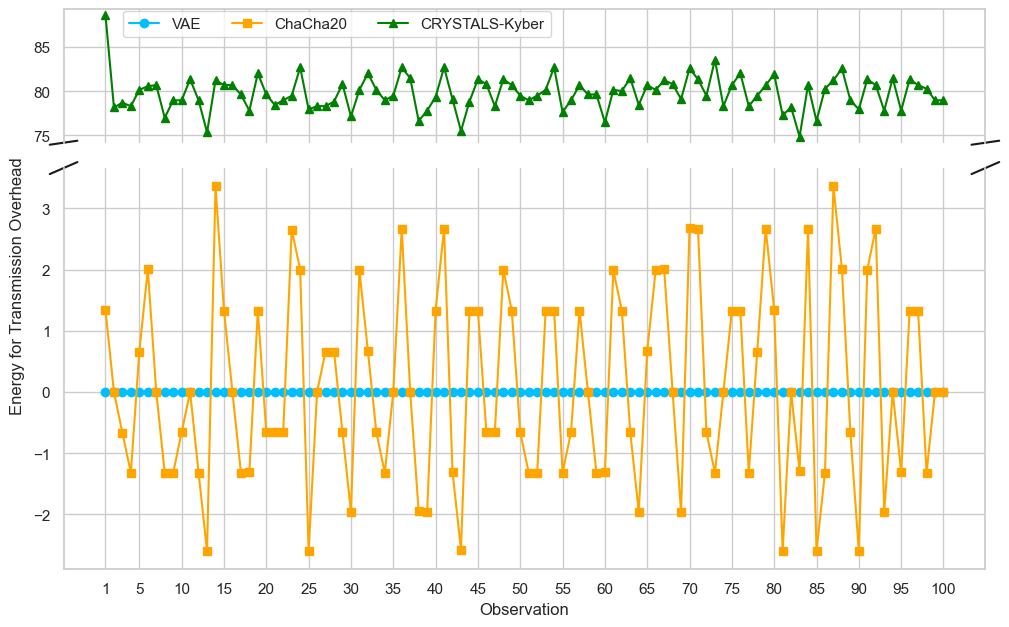

In [431]:
#import matplotlib.pyplot as plt

# Filter each method
#vae_df = df[df['Method'] == 'VAE'].reset_index(drop=True)
#chacha_df = df[df['Method'] == 'ChaCha20'].reset_index(drop=True)
#kyber_df = df[df['Method'] == 'CRYSTALS-Kyber'].reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(10, 7),
    gridspec_kw={'height_ratios': [1, 3]}
)

# --- Upper axis (Kyber) ---
line_kyber, = ax1.plot(
    kyber_df.index + 1,
    kyber_df['Energy_transmission_overhead'],
    marker='^',
    linestyle='-',
    color='green',
    label='CRYSTALS-Kyber'
)

# --- Lower axis (VAE + ChaCha20) ---
line_vae, = ax2.plot(
    vae_df.index + 1,
    vae_df['Energy_transmission_overhead'],
    marker='o',
    linestyle='-',
    color='deepskyblue',
    label='VAE'
)

line_chacha, = ax2.plot(
    chacha_df.index + 1,
    chacha_df['Energy_transmission_overhead'],
    marker='s',
    linestyle='-',
    color='orange',
    label='ChaCha20'
)

# --- Broken axis styling ---
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.tick_params(labeltop=False)

d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# --- Labels ---
#fig.suptitle('Comparison: Energy for Transmission Overhead', fontsize=14)
ax2.set_xlabel('Observation')
#ax1.set_ylabel('Energy')
#ax2.set_ylabel('Energy')
fig.text(-0.005, 0.5, 'Energy for Transmission Overhead', va='center', rotation='vertical')


ax1.grid(True)
ax2.grid(True)

ax2.set_xticks([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100])

# Single shared legend
fig.legend(
    handles=[line_vae, line_chacha, line_kyber],
    loc='upper left',
    ncol=3,
    bbox_to_anchor=(0.1, 0.902),  # INSIDE the figure
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


##### Transmission performance

Transmission time (seconds) vs Airtime overhead (%)

In [340]:
'''
import matplotlib.pyplot as plt

# Filter each method
vae_df = df[df['Method'] == 'VAE']
chacha_df = df[df['Method'] == 'ChaCha20']
kyber_df = df[df['Method'] == 'CRYSTALS-Kyber']

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# --- VAE ---
axes[0].plot(
    vae_df['Transmission_time'],
    vae_df['Airtime_overhead'],
    marker='o',
    linestyle='-'
)
axes[0].set_title('VAE', fontsize=16)
axes[0].set_xlabel('Transmission time', fontsize=16)
axes[0].set_ylabel('Airtime overhead', fontsize=16)
axes[0].grid(True)

# --- ChaCha20 ---
axes[1].plot(
    chacha_df['Transmission_time'],
    chacha_df['Airtime_overhead'],
    marker='s',
    linestyle='-'
)
axes[1].set_title('ChaCha20', fontsize=16)
axes[1].set_xlabel('Transmission time', fontsize=16)
axes[1].grid(True)

# --- CRYSTALS-Kyber ---
axes[2].plot(
    kyber_df['Transmission_time'],
    kyber_df['Airtime_overhead'],
    marker='^',
    linestyle='-'
)
axes[2].set_title('CRYSTALS-Kyber', fontsize=16)
axes[2].set_xlabel('Transmission time', fontsize=16)
axes[2].grid(True)

# Overall title
fig.suptitle('Transmission time vs Airtime overhead', fontsize=20)

plt.tight_layout()
plt.show()
'''

"\nimport matplotlib.pyplot as plt\n\n# Filter each method\nvae_df = df[df['Method'] == 'VAE']\nchacha_df = df[df['Method'] == 'ChaCha20']\nkyber_df = df[df['Method'] == 'CRYSTALS-Kyber']\n\n# Create subplots: 1 row, 3 columns\nfig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)\n\n# --- VAE ---\naxes[0].plot(\n    vae_df['Transmission_time'],\n    vae_df['Airtime_overhead'],\n    marker='o',\n    linestyle='-'\n)\naxes[0].set_title('VAE', fontsize=16)\naxes[0].set_xlabel('Transmission time', fontsize=16)\naxes[0].set_ylabel('Airtime overhead', fontsize=16)\naxes[0].grid(True)\n\n# --- ChaCha20 ---\naxes[1].plot(\n    chacha_df['Transmission_time'],\n    chacha_df['Airtime_overhead'],\n    marker='s',\n    linestyle='-'\n)\naxes[1].set_title('ChaCha20', fontsize=16)\naxes[1].set_xlabel('Transmission time', fontsize=16)\naxes[1].grid(True)\n\n# --- CRYSTALS-Kyber ---\naxes[2].plot(\n    kyber_df['Transmission_time'],\n    kyber_df['Airtime_overhead'],\n    marker='^',\n    line

###### Transmission energy

Energy consumption for transmission (joules) vs Energy for transmission overhead (%)

In [341]:
'''
import matplotlib.pyplot as plt

# Filter each method
vae_df = df[df['Method'] == 'VAE']
chacha_df = df[df['Method'] == 'ChaCha20']
kyber_df = df[df['Method'] == 'CRYSTALS-Kyber']

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# --- VAE ---
axes[0].plot(
    vae_df['Energy_for_transmission'],
    vae_df['Energy_transmission_overhead'],
    marker='o',
    linestyle='-'
)
axes[0].set_title('VAE', fontsize=16)
axes[0].set_xlabel('Energy for transmission (Joules)', fontsize=16)
axes[0].set_ylabel('Energy transmission overhead (%)', fontsize=16)
axes[0].grid(True)

# --- ChaCha20 ---
axes[1].plot(
    chacha_df['Energy_for_transmission'],
    chacha_df['Energy_transmission_overhead'],
    marker='s',
    linestyle='-'
)
axes[1].set_title('ChaCha20', fontsize=16)
axes[1].set_xlabel('Energy for transmission (Joules)', fontsize=16)
axes[1].grid(True)

# --- CRYSTALS-Kyber ---
axes[2].plot(
    kyber_df['Energy_for_transmission'],
    kyber_df['Energy_transmission_overhead'],
    marker='^',
    linestyle='-'
)
axes[2].set_title('CRYSTALS-Kyber')
axes[2].set_xlabel('Energy for transmission (Joules)', fontsize=16)
axes[2].grid(True)

# Overall title
fig.suptitle('Energy for transmission (Joules) vs Energy transmission overhead (%)', fontsize=20)

plt.tight_layout()
plt.show()
'''

"\nimport matplotlib.pyplot as plt\n\n# Filter each method\nvae_df = df[df['Method'] == 'VAE']\nchacha_df = df[df['Method'] == 'ChaCha20']\nkyber_df = df[df['Method'] == 'CRYSTALS-Kyber']\n\n# Create subplots: 1 row, 3 columns\nfig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)\n\n# --- VAE ---\naxes[0].plot(\n    vae_df['Energy_for_transmission'],\n    vae_df['Energy_transmission_overhead'],\n    marker='o',\n    linestyle='-'\n)\naxes[0].set_title('VAE', fontsize=16)\naxes[0].set_xlabel('Energy for transmission (Joules)', fontsize=16)\naxes[0].set_ylabel('Energy transmission overhead (%)', fontsize=16)\naxes[0].grid(True)\n\n# --- ChaCha20 ---\naxes[1].plot(\n    chacha_df['Energy_for_transmission'],\n    chacha_df['Energy_transmission_overhead'],\n    marker='s',\n    linestyle='-'\n)\naxes[1].set_title('ChaCha20', fontsize=16)\naxes[1].set_xlabel('Energy for transmission (Joules)', fontsize=16)\naxes[1].grid(True)\n\n# --- CRYSTALS-Kyber ---\naxes[2].plot(\n    kyber_df['

In [344]:
'''
#import matplotlib.pyplot as plt

# Filter each method
vae_df = df[df['Method'] == 'VAE']
chacha_df = df[df['Method'] == 'ChaCha20']
kyber_df = df[df['Method'] == 'CRYSTALS-Kyber']

plt.figure(figsize=(9,6))

# Scatter plots
plt.scatter(
    vae_df['Transmission_time'],
    vae_df['Energy_for_transmission'],
    marker='o',
    label='VAE'
)

plt.scatter(
    chacha_df['Transmission_time'],
    chacha_df['Energy_for_transmission'],
    marker='s',
    label='ChaCha20'
)

plt.scatter(
    kyber_df['Transmission_time'],
    kyber_df['Energy_for_transmission'],
    marker='^',
    label='CRYSTALS-Kyber'
)

# Labels and styling
plt.title('Transmission time vs Energy for transmission')
plt.xlabel('Transmission time')
plt.ylabel('Energy for transmission')
plt.grid(True)
plt.legend()
plt.show()
'''

"\n#import matplotlib.pyplot as plt\n\n# Filter each method\nvae_df = df[df['Method'] == 'VAE']\nchacha_df = df[df['Method'] == 'ChaCha20']\nkyber_df = df[df['Method'] == 'CRYSTALS-Kyber']\n\nplt.figure(figsize=(9,6))\n\n# Scatter plots\nplt.scatter(\n    vae_df['Transmission_time'],\n    vae_df['Energy_for_transmission'],\n    marker='o',\n    label='VAE'\n)\n\nplt.scatter(\n    chacha_df['Transmission_time'],\n    chacha_df['Energy_for_transmission'],\n    marker='s',\n    label='ChaCha20'\n)\n\nplt.scatter(\n    kyber_df['Transmission_time'],\n    kyber_df['Energy_for_transmission'],\n    marker='^',\n    label='CRYSTALS-Kyber'\n)\n\n# Labels and styling\nplt.title('Transmission time vs Energy for transmission')\nplt.xlabel('Transmission time')\nplt.ylabel('Energy for transmission')\nplt.grid(True)\nplt.legend()\nplt.show()\n"

In [343]:
'''
import matplotlib.pyplot as plt

# Filter each method
vae_df = df[df['Method'] == 'VAE']
chacha_df = df[df['Method'] == 'ChaCha20']
kyber_df = df[df['Method'] == 'CRYSTALS-Kyber']

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# --- VAE ---
axes[0].plot(
    vae_df['Transmission_time'],
    vae_df['Energy_for_transmission'],
    marker='o',
    linestyle='-'
)
axes[0].set_title('VAE', fontsize=16)
axes[0].set_xlabel('Energy for transmission (Joules)', fontsize=16)
axes[0].set_ylabel('Transmission_time (seconds)', fontsize=16)
axes[0].grid(True)

# --- ChaCha20 ---
axes[1].plot(
    chacha_df['Energy_for_transmission'],
    chacha_df['Transmission_time'],
    marker='s',
    linestyle='-'
)
axes[1].set_title('ChaCha20', fontsize=16)
axes[1].set_xlabel('Energy for transmission (Joules)', fontsize=16)
axes[1].grid(True)

# --- CRYSTALS-Kyber ---
axes[2].plot(
    kyber_df['Transmission_time'],
    kyber_df['Energy_transmission_overhead'],
    marker='^',
    linestyle='-'
)
axes[2].set_title('CRYSTALS-Kyber')
axes[2].set_xlabel('Energy for transmission (Joules)', fontsize=16)
axes[2].grid(True)

# Overall title
fig.suptitle('Energy for transmission (Joules) vs Energy transmission overhead (%)', fontsize=20)

plt.tight_layout()
plt.show()
'''

"\nimport matplotlib.pyplot as plt\n\n# Filter each method\nvae_df = df[df['Method'] == 'VAE']\nchacha_df = df[df['Method'] == 'ChaCha20']\nkyber_df = df[df['Method'] == 'CRYSTALS-Kyber']\n\n# Create subplots: 1 row, 3 columns\nfig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)\n\n# --- VAE ---\naxes[0].plot(\n    vae_df['Transmission_time'],\n    vae_df['Energy_for_transmission'],\n    marker='o',\n    linestyle='-'\n)\naxes[0].set_title('VAE', fontsize=16)\naxes[0].set_xlabel('Energy for transmission (Joules)', fontsize=16)\naxes[0].set_ylabel('Transmission_time (seconds)', fontsize=16)\naxes[0].grid(True)\n\n# --- ChaCha20 ---\naxes[1].plot(\n    chacha_df['Energy_for_transmission'],\n    chacha_df['Transmission_time'],\n    marker='s',\n    linestyle='-'\n)\naxes[1].set_title('ChaCha20', fontsize=16)\naxes[1].set_xlabel('Energy for transmission (Joules)', fontsize=16)\naxes[1].grid(True)\n\n# --- CRYSTALS-Kyber ---\naxes[2].plot(\n    kyber_df['Transmission_time'],\n    k

#### Payload impact

Encryption overhead (%) vs Airtime overhead (%)

In [342]:
'''
import matplotlib.pyplot as plt

# Filter each method
vae_df = df[df['Method'] == 'VAE']
chacha_df = df[df['Method'] == 'ChaCha20']
kyber_df = df[df['Method'] == 'CRYSTALS-Kyber']

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# --- VAE ---
axes[0].plot(
    vae_df['Energy_encryption_overhead'],
    vae_df['Airtime_overhead'],
    marker='o',
    linestyle='-'
)
axes[0].set_title('VAE', fontsize=16)
axes[0].set_xlabel('Energy encryption overhead (%)', fontsize=16)
axes[0].set_ylabel('Airtime overhead (%)', fontsize=16)
axes[0].grid(True)

# --- ChaCha20 ---
axes[1].plot(
    chacha_df['Energy_encryption_overhead'],
    chacha_df['Airtime_overhead'],
    marker='s',
    linestyle='-'
)
axes[1].set_title('ChaCha20', fontsize=16)
axes[1].set_xlabel('Energy encryption overhead (%)', fontsize=16)
axes[1].grid(True)

# --- CRYSTALS-Kyber ---
axes[2].plot(
    kyber_df['Energy_encryption_overhead'],
    kyber_df['Airtime_overhead'],
    marker='^',
    linestyle='-'
)
axes[2].set_title('CRYSTALS-Kyber', fontsize=16)
axes[2].set_xlabel('Energy encryption overhead (%)', fontsize=16)
axes[2].grid(True)

# Overall title
fig.suptitle('Energy for transmission (Joules) vs Energy transmission overhead (%)', fontsize=20)

plt.tight_layout()
plt.show()
'''

"\nimport matplotlib.pyplot as plt\n\n# Filter each method\nvae_df = df[df['Method'] == 'VAE']\nchacha_df = df[df['Method'] == 'ChaCha20']\nkyber_df = df[df['Method'] == 'CRYSTALS-Kyber']\n\n# Create subplots: 1 row, 3 columns\nfig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)\n\n# --- VAE ---\naxes[0].plot(\n    vae_df['Energy_encryption_overhead'],\n    vae_df['Airtime_overhead'],\n    marker='o',\n    linestyle='-'\n)\naxes[0].set_title('VAE', fontsize=16)\naxes[0].set_xlabel('Energy encryption overhead (%)', fontsize=16)\naxes[0].set_ylabel('Airtime overhead (%)', fontsize=16)\naxes[0].grid(True)\n\n# --- ChaCha20 ---\naxes[1].plot(\n    chacha_df['Energy_encryption_overhead'],\n    chacha_df['Airtime_overhead'],\n    marker='s',\n    linestyle='-'\n)\naxes[1].set_title('ChaCha20', fontsize=16)\naxes[1].set_xlabel('Energy encryption overhead (%)', fontsize=16)\naxes[1].grid(True)\n\n# --- CRYSTALS-Kyber ---\naxes[2].plot(\n    kyber_df['Energy_encryption_overhead'],\n   

In [220]:
df.head(1)

,Method,File_size,Encryption_overhead,Energy_for_compression_encryption,Energy_encryption_overhead,Transmission_time,Airtime_overhead,Energy_for_transmission,Energy_transmission_overhead
0,CRYSTALS-Kyber,1800,77.17,3.86,-2.03,9.08,80.88,2.81,88.59


## Metrics

In [348]:
# Transmission time mean and median
metrics_Energy_for_compression_encryption = df.groupby('Method')['Energy_for_compression_encryption'].agg(['mean', 'median', 'std']).reset_index()
metrics_Energy_for_compression_encryption

,Method,mean,median,std
0,CRYSTALS-Kyber,3.8354,3.84,0.071850
1,ChaCha20,3.7931,3.80,0.068249
2,VAE,3.8043,3.80,0.074958


In [350]:
# Transmission time mean and median
metrics_Transmission_time = df.groupby('Method')['Transmission_time'].agg(['mean', 'median', 'std']).reset_index()
metrics_Transmission_time

,Method,mean,median,std
0,CRYSTALS-Kyber,9.0515,9.050,0.007833
1,ChaCha20,5.0261,5.030,0.004902
2,VAE,5.0253,5.025,0.005766


In [349]:
# Transmission time mean and median
metrics_Energy_for_transmission = df.groupby('Method')['Energy_for_transmission'].agg(['mean', 'median', 'std']).reset_index()
metrics_Energy_for_transmission

,Method,mean,median,std
0,CRYSTALS-Kyber,2.7192,2.72,0.017904
1,ChaCha20,1.5141,1.51,0.014005
2,VAE,1.5128,1.51,0.014290


In [351]:
# Transmission time mean and median
metrics_Energy_encryption_overhead = df.groupby('Method')['Energy_encryption_overhead'].agg(['mean', 'median', 'std']).reset_index()
metrics_Energy_encryption_overhead

,Method,mean,median,std
0,CRYSTALS-Kyber,0.8472,0.81,2.395131
1,ChaCha20,-0.2470,-0.13,2.995171
2,VAE,0.0000,0.00,0.000000


In [352]:
# Transmission time mean and median
metrics_Airtime_overhead = df.groupby('Method')['Airtime_overhead'].agg(['mean', 'median', 'std']).reset_index()
metrics_Airtime_overhead

,Method,mean,median,std
0,CRYSTALS-Kyber,80.1193,80.12,0.253892
1,ChaCha20,0.0161,0.00,0.162125
2,VAE,0.0000,0.00,0.000000


In [353]:
# Transmission time mean and median
metrics_Energy_transmission_overhead = df.groupby('Method')['Energy_transmission_overhead'].agg(['mean', 'median', 'std']).reset_index()
metrics_Energy_transmission_overhead

,Method,mean,median,std
0,CRYSTALS-Kyber,79.7611,79.61,1.956697
1,ChaCha20,0.0975,0.00,1.582857
2,VAE,0.0000,0.00,0.000000
